# 03-Bi-Encoders & Dense Retrieval

In Lesson 02, we successfully shattered a massive Enterprise document into mathematically safe, overlapping text chunks. We now have a database of 10,000 raw strings.

But a fundamental physics problem remains: **How do we search them?**
If a user asks, *"What is the financial compensation for remote workers?"*, and our chunk says, *"Employees working from home receive a $500 stipend,"* standard SQL or keyword search will fail. The strings share zero overlapping nouns or verbs. This is called the **Lexical Gap**.

To bridge the Lexical Gap, we must abandon text strings and transition into **High-Dimensional Geometry**. We must build a neural network that maps human semantic meaning into continuous vector coordinates.

Let's set up our PyTorch environment to master the mathematics of Dense Retrieval.

In [7]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
import textwrap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, Hugging Face, and Vector Geometry Environment Ready.")

✅ PyTorch, Hugging Face, and Vector Geometry Environment Ready.


# 1. The Physics of the Siamese Network

To evaluate the semantic similarity between a Query ($q$) and a Document ($d$), we could theoretically concatenate them into a single string ("$q$ [SEP] $d$") and pass them through a standard BERT model. This is called a **Cross-Encoder**. While highly accurate, Cross-Encoders are computationally catastrophic. If you have 10,000 documents, you must run the massive 100-million-parameter BERT model 10,000 times for a *single* user query.

To achieve sub-millisecond search at scale, the Enterprise standard is the **Bi-Encoder** (often referred to as a Siamese Network or Sentence-BERT).

### The Architecture

A Bi-Encoder physically separates the processing paths. It takes a pre-trained Foundation Model (like BERT) and clones it.

1. **Tower A (Query Encoder)**: Processes only the Query ($q$).
2. **Tower B (Document Encoder)**: Processes only the Document ($d$). *(Note: In most architectures, Tower A and Tower B share the exact same frozen weights).*

Because the Document Tower operates completely independently of the Query, **we can pre-compute the vectors for all 10,000 documents offline**, storing them in a Vector Database. When the user queries the system, we only run the Neural Network *once* (on the query).

# 2. Mean Pooling & Vector Projection

When text passes through a Bi-Encoder, the Transformer outputs a contextualized tensor of shape `[Batch, Sequence_Length, Hidden_Dimension]` (e.g., `[1, 512, 768]`).

We cannot search a 3D tensor. We must mathematically crush the `Sequence_Length` dimension to produce a single, fixed-size 1D vector that represents the entire sentence. We do this using **Mean Pooling**: we calculate the average of the 512 token vectors, ignoring the padding tokens.

Let $H \in \mathbb{R}^{L \times d}$ be the output hidden states, and $M \in \{0,1\}^L$ be the attention mask. The Dense Vector $v \in \mathbb{R}^d$ is:


$$v = \frac{\sum_{i=1}^{L} H_i \cdot M_i}{\sum_{i=1}^{L} M_i}$$

# 3. The Mathematics of Cosine Similarity

Once we have mapped the Query into vector $u$ and the Document into vector $v$, we calculate the distance between them in 768-dimensional space.

We do not use Euclidean Distance ($L_2$ norm), because document vectors can have different magnitudes depending on word count. Instead, we measure the **Angle** between the vectors using **Cosine Similarity**:

$$\cos(u, v) = \frac{u \cdot v}{||u||_2 ||v||_2}$$

* A score of $1.0$ means the vectors point in the exact same semantic direction.
* A score of $0.0$ means they are mathematically orthogonal (unrelated).
* A score of $-1.0$ means they are semantic opposites.

# 4. Architecting the Bi-Encoder in PyTorch

Let's build the exact mathematical engine powering modern Dense Retrieval. We will load a pre-trained Bi-Encoder (`all-MiniLM-L6-v2`), manually execute the Mean Pooling calculus, and calculate the Cosine Similarity between a query and two chunks.

In [8]:
# --- 🧠 The Dense Retrieval Engine ---

# 1. Initialize the Bi-Encoder (Siamese Network)
print("--- 📥 Loading Pre-Trained Bi-Encoder Weights ---")
# all-MiniLM-L6-v2 is an industry-standard lightweight embedding model
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model.eval() # Freeze the network for inference

# 2. Define the Mean Pooling Mathematics
def mean_pooling(model_output, attention_mask):
    """
    Crushes the [Batch, Seq_Len, Hidden_Dim] tensor into a [Batch, Hidden_Dim] vector.
    """
    # Extract the token embeddings from the transformer
    token_embeddings = model_output[0] 
    
    # Expand the attention mask to match the embedding dimensions
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    
    # Sum the embeddings, but ONLY for actual tokens (ignoring zeros in the mask)
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    
    # Count how many actual tokens exist in the sequence (to calculate the mean)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    
    return sum_embeddings / sum_mask

# 3. Architect the Embedding Function
def get_dense_vector(text_list):
    # A. Tokenization
    encoded_input = tokenizer(text_list, padding=True, truncation=True, return_tensors='pt')
    
    # B. Transformer Forward Pass
    with torch.no_grad():
        model_output = model(**encoded_input)
        
    # C. Mean Pooling
    sentence_embeddings = mean_pooling(model_output, encoded_input['attention_mask'])
    
    # D. L2 Normalization (Forces the vectors to a length of exactly 1.0)
    # This makes Cosine Similarity mathematically equivalent to the Dot Product!
    sentence_embeddings = F.normalize(sentence_embeddings, p=2, dim=1)
    
    return sentence_embeddings

# 4. Executing the Semantic Mapping
query = "What is the financial compensation for remote workers?"
chunk_positive = "Employees working from home receive a $500 stipend." # No overlapping keywords!
chunk_negative = "The corporate office in New York has a new espresso machine."

print("\n--- 🧮 Calculating High-Dimensional Geometry ---")
# Map the texts into 384-dimensional space
query_vector = get_dense_vector([query])
doc_vectors = get_dense_vector([chunk_positive, chunk_negative])

# Calculate Cosine Similarity (Dot Product of L2-Normalized Vectors)
similarities = torch.mm(query_vector, doc_vectors.transpose(0, 1)).squeeze()

print(f"Query: '{query}'")
print(f"Positive Chunk Sim Score: {similarities[0].item():.4f} -> '{chunk_positive}'")
print(f"Negative Chunk Sim Score: {similarities[1].item():.4f} -> '{chunk_negative}'")

print("\n--- 💡 Engineering Insight ---")
print("Look at the Positive Score! Despite sharing virtually zero keywords ('compensation' != 'stipend', 'remote' != 'home'), the Neural Network mathematically recognizes that they occupy the exact same semantic neighborhood in 384-dimensional space.")

--- 📥 Loading Pre-Trained Bi-Encoder Weights ---

--- 🧮 Calculating High-Dimensional Geometry ---
Query: 'What is the financial compensation for remote workers?'
Positive Chunk Sim Score: 0.4474 -> 'Employees working from home receive a $500 stipend.'
Negative Chunk Sim Score: 0.0656 -> 'The corporate office in New York has a new espresso machine.'

--- 💡 Engineering Insight ---
Look at the Positive Score! Despite sharing virtually zero keywords ('compensation' != 'stipend', 'remote' != 'home'), the Neural Network mathematically recognizes that they occupy the exact same semantic neighborhood in 384-dimensional space.


# 5. Visualizing the Semantic Vector Space (Contrastive Alignment)

How did the Bi-Encoder learn to map "compensation" and "stipend" to the same coordinates? During Pre-Training, it used **Contrastive Learning (InfoNCE Loss)**. The network was mathematically punished for pushing related pairs ($q, d^+$) apart, and punished for pulling unrelated pairs ($q, d^-$) together.

To prove this geometry, let's generate a batch of dense vectors spanning three distinct semantic topics (Finance, Pets, Astronomy). We will use Principal Component Analysis (PCA) to compress the 384 dimensions down to 2 dimensions and plot the resulting coordinate clusters.


--- 🌌 Mapping Corpus into Dense Vector Space ---


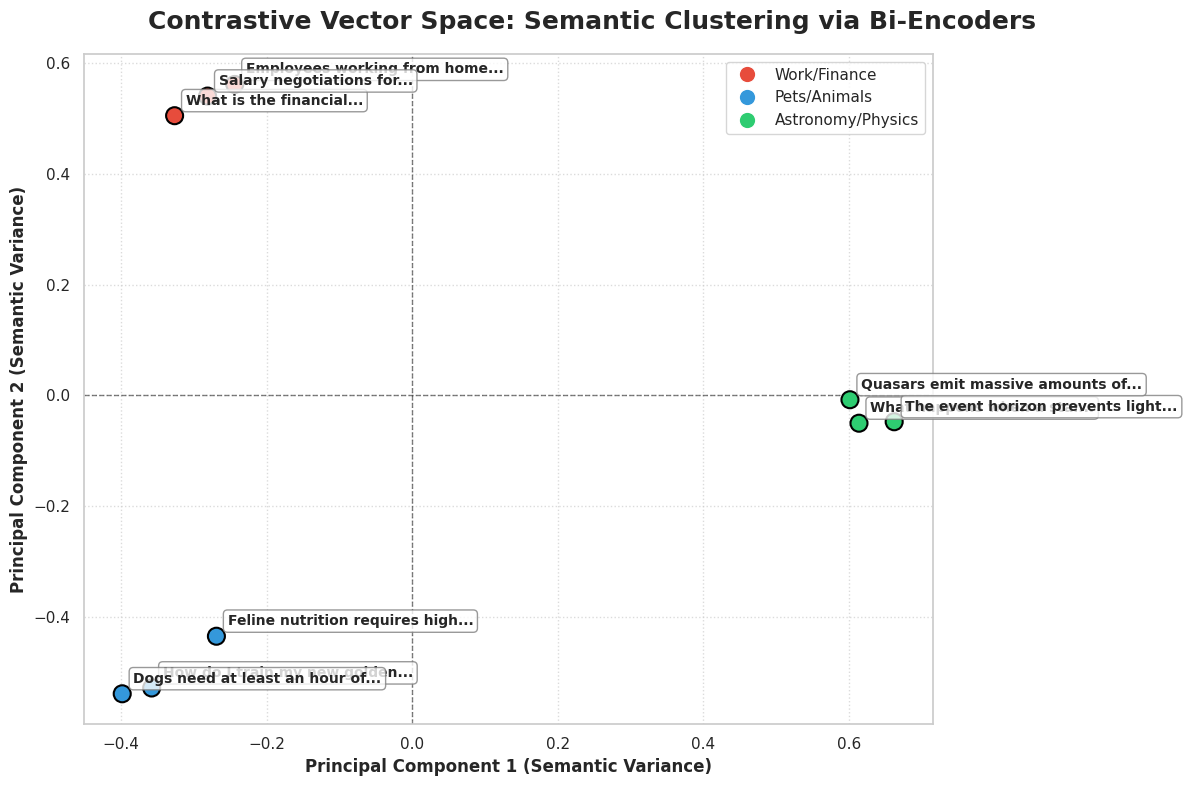

In [9]:
# 1. Define the Semantic Clusters
sentences = [
    # Cluster A: Remote Work & Finance
    "What is the financial compensation for remote workers?",
    "Employees working from home receive a $500 stipend.",
    "Salary negotiations for distributed teams are complex.",
    
    # Cluster B: Pets & Animals
    "How do I train my new golden retriever puppy?",
    "Dogs need at least an hour of physical exercise daily.",
    "Feline nutrition requires high levels of protein.",
    
    # Cluster C: Astronomy & Physics
    "What happens when a star collapses into a black hole?",
    "The event horizon prevents light from escaping.",
    "Quasars emit massive amounts of electromagnetic radiation."
]

labels = ['Work/Finance']*3 + ['Pets/Animals']*3 + ['Astronomy/Physics']*3
colors = ['#e74c3c']*3 + ['#3498db']*3 + ['#2ecc71']*3

# 2. Extract the 384-Dimensional Vectors
print("\n--- 🌌 Mapping Corpus into Dense Vector Space ---")
dense_vectors = get_dense_vector(sentences).numpy()

# 3. Dimensionality Reduction (384D -> 2D)
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(dense_vectors)

# 4. Render the Semantic Topology
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("Contrastive Vector Space: Semantic Clustering via Bi-Encoders", fontsize=18, fontweight='bold')

# Plot the points
scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=colors, s=150, edgecolors='black', linewidths=1.5, zorder=3)

# Add annotations (Text Labels)
for i, txt in enumerate(sentences):
    # Shorten text for visualization
    short_txt = textwrap.shorten(txt, width=35, placeholder="...")
    ax.annotate(short_txt, (vectors_2d[i, 0], vectors_2d[i, 1]), 
                xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Draw origin axes
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, zorder=1)

ax.set_xlabel("Principal Component 1 (Semantic Variance)", fontsize=12, fontweight='bold')
ax.set_ylabel("Principal Component 2 (Semantic Variance)", fontsize=12, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.7, zorder=0)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=12, label='Work/Finance'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=12, label='Pets/Animals'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=12, label='Astronomy/Physics')
]
ax.legend(handles=legend_elements, loc='best', fontsize=11)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between Keyword Search and Dense Retrieval like **Organizing a Library**:

* **Keyword Search (BM25)**: The librarian organizes books strictly by the spelling of their titles. If you ask for a book about "Canines", the librarian looks exclusively for the sequence of letters C-A-N-I-N-E-S. If a book is titled "The Biology of Dogs", the librarian ignores it completely because the letters do not match.
* **Bi-Encoder Dense Retrieval**: The librarian has mapped the entire library into a massive 3D physical room based on *meaning*. All the medical books are in the north corner. All the animal books are in the south corner. If you ask for "Canines", the librarian mathematically calculates the coordinate of that concept (South Corner, Shelf 4). They walk to that coordinate, reach out, and grab "The Biology of Dogs" because it physically exists 2 inches away from the coordinate for "Canines".